In [1]:
import json
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
plt.rcParams["font.size"] = 11

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

Ячейка 2 — загрузка JSON

In [3]:
JSON_PATH = Path(r"C:\Users\kotof\Study\Diploma\prog_GPU\results\20260426_011853__baseline_gpu\suite_result.json")  # поменяй путь при необходимости

with JSON_PATH.open("r", encoding="utf-8") as f:
    raw = json.load(f)

print("suite_name:", raw["suite_name"])
print("created_at:", raw["created_at"])
print("scenarios:", len(raw["scenario_results"]))

suite_name: baseline_gpu
created_at: 2026-04-26T01:18:52
scenarios: 12


Ячейка 3 — разбор scenario_key и сбор таблиц

In [4]:
def parse_num_token(token: str):
    token = token.replace("p", ".")
    return float(token) if "." in token else int(token)

SCENARIO_RE = re.compile(
    r"arrival__arr-(?P<arrival>.+?)__work-(?P<workload>.+?)__lam-(?P<lam>[\dp]+)__sig-(?P<sig>[\dp]+)$"
)

def parse_scenario_key(scenario_key: str) -> dict:
    m = SCENARIO_RE.match(scenario_key)
    if not m:
        return {
            "arrival": None,
            "workload": None,
            "lambda_value": None,
            "sigma": None,
        }
    return {
        "arrival": m.group("arrival"),
        "workload": m.group("workload"),
        "lambda_value": parse_num_token(m.group("lam")),
        "sigma": parse_num_token(m.group("sig")),
    }

metric_rows = []
pi_rows = []

for scenario_key, scenario_data in raw["scenario_results"].items():
    meta = parse_scenario_key(scenario_key)
    scenario_name = scenario_data.get("scenario_name", scenario_key)
    replications = scenario_data.get("replications")

    for metric_name, ms in scenario_data.get("metric_summaries", {}).items():
        row = {
            "suite_name": raw.get("suite_name"),
            "created_at": raw.get("created_at"),
            "scenario_key": scenario_key,
            "scenario_name": scenario_name,
            "replications": replications,
            **meta,
            "metric": metric_name,
            "n": ms.get("n"),
            "mean": ms.get("mean"),
            "std": ms.get("std"),
            "stderr": ms.get("stderr"),
            "ci_level": ms.get("ci_level"),
            "ci_low": ms.get("ci_low"),
            "ci_high": ms.get("ci_high"),
            "min_value": ms.get("min_value"),
            "max_value": ms.get("max_value"),
        }
        metric_rows.append(row)

        if metric_name.startswith("pi_hat_"):
            state = int(metric_name.split("_")[-1])
            pi_rows.append({**row, "state": state})

metrics_df = pd.DataFrame(metric_rows).sort_values(
    ["arrival", "workload", "lambda_value", "sigma", "metric"]
).reset_index(drop=True)

pi_df = pd.DataFrame(pi_rows).sort_values(
    ["arrival", "workload", "lambda_value", "sigma", "state"]
).reset_index(drop=True)

base_metrics_df = metrics_df.loc[~metrics_df["metric"].str.startswith("pi_hat_")].copy()

print("base_metrics_df:", base_metrics_df.shape)
print("pi_df:", pi_df.shape)

base_metrics_df: (192, 19)
pi_df: (1164, 20)


Ячейка 4 — быстрый просмотр, что вообще есть в данных

In [5]:
print("Available metrics:")
display(sorted(base_metrics_df["metric"].unique()))

print("\nAvailable scenario combinations:")
display(
    base_metrics_df[
        ["arrival", "workload", "lambda_value", "sigma"]
    ]
    .drop_duplicates()
    .sort_values(["arrival", "workload", "lambda_value", "sigma"])
    .reset_index(drop=True)
    .head(30)
)

Available metrics:


['accepted_arrivals',
 'arrival_attempts',
 'completed_jobs',
 'completed_time_samples',
 'loss_probability',
 'mean_num_jobs',
 'mean_occupied_resource',
 'mean_service_time',
 'mean_sojourn_time',
 'rejected_arrivals',
 'rejected_capacity',
 'rejected_resource',
 'rejected_server',
 'std_service_time',
 'std_sojourn_time',
 'throughput']


Available scenario combinations:


,arrival,workload,lambda_value,sigma
0,erlang_2,exponential,70.0,1.2
1,erlang_2,exponential,82.2,1.2
2,erlang_2,exponential,90.0,1.2
3,erlang_4,exponential,70.0,1.2
4,erlang_4,exponential,82.2,1.2
5,erlang_4,exponential,90.0,1.2
6,hyperexp_2,exponential,70.0,1.2
7,hyperexp_2,exponential,82.2,1.2
8,hyperexp_2,exponential,90.0,1.2
9,poisson,exponential,70.0,1.2


Ячейка 5 — общие функции для графиков

In [6]:
def filter_df(df: pd.DataFrame, **filters) -> pd.DataFrame:
    out = df.copy()
    for col, value in filters.items():
        if value is None:
            continue
        if isinstance(value, (list, tuple, set)):
            out = out[out[col].isin(value)]
        else:
            out = out[out[col] == value]
    return out


def add_series_label(df: pd.DataFrame, cols=("arrival", "workload")) -> pd.DataFrame:
    out = df.copy()
    out["series"] = out[list(cols)].astype(str).agg(" | ".join, axis=1)
    return out


def plot_metric_panels(
    df,
    metric,
    x,
    panel,
    filters=None,
    series_cols=("arrival", "workload"),
    ci=True,
    suptitle=None,
):
    data = df[df["metric"] == metric].copy()
    if filters:
        data = filter_df(data, **filters)

    if data.empty:
        raise ValueError(f"No data for metric={metric} with filters={filters}")

    data = add_series_label(data, series_cols)
    panel_values = sorted(pd.unique(data[panel]))
    n_panels = len(panel_values)

    fig, axes = plt.subplots(1, n_panels, figsize=(6 * n_panels, 4.8), sharey=True)
    if n_panels == 1:
        axes = [axes]

    for ax, panel_value in zip(axes, panel_values):
        sdf = data[data[panel] == panel_value].copy()

        for label, g in sdf.groupby("series"):
            g = g.sort_values(x)
            ax.plot(g[x], g["mean"], marker="o", label=label)
            if ci:
                ax.fill_between(g[x], g["ci_low"], g["ci_high"], alpha=0.15)

        ax.set_title(f"{panel} = {panel_value}")
        ax.set_xlabel(x)
        ax.set_ylabel(metric)

    handles, labels = axes[0].get_legend_handles_labels()
    if handles:
        fig.legend(
            handles,
            labels,
            loc="upper center",
            ncol=min(4, len(labels)),
            bbox_to_anchor=(0.5, 1.08),
        )

    if suptitle:
        fig.suptitle(suptitle, y=1.14, fontsize=13)

    fig.tight_layout()
    plt.show()


def plot_heatmap(df, metric, arrival, workload, value_col="mean", title=None, annotate=True):
    data = filter_df(df, metric=metric, arrival=arrival, workload=workload)

    if data.empty:
        raise ValueError(f"No data for metric={metric}, arrival={arrival}, workload={workload}")

    pivot = (
        data.pivot_table(
            index="sigma",
            columns="lambda_value",
            values=value_col,
            aggfunc="mean",
        )
        .sort_index()
        .sort_index(axis=1)
    )

    fig, ax = plt.subplots(figsize=(8, 5.5))
    im = ax.imshow(pivot.values, aspect="auto")
    plt.colorbar(im, ax=ax, label=f"{metric} ({value_col})")

    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels([str(x) for x in pivot.columns])
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels([str(y) for y in pivot.index])

    ax.set_xlabel("lambda_value")
    ax.set_ylabel("sigma")
    ax.set_title(title or f"{metric}: {arrival} | {workload}")

    if annotate:
        for i in range(pivot.shape[0]):
            for j in range(pivot.shape[1]):
                val = pivot.iloc[i, j]
                if pd.notna(val):
                    ax.text(j, i, f"{val:.4g}", ha="center", va="center", fontsize=9)

    plt.tight_layout()
    plt.show()


def plot_grouped_bars(df, metric, compare_col, x_col="lambda_value", filters=None, title=None):
    data = df[df["metric"] == metric].copy()
    if filters:
        data = filter_df(data, **filters)

    if data.empty:
        raise ValueError(f"No data for metric={metric} with filters={filters}")

    x_vals = sorted(pd.unique(data[x_col]))
    groups = sorted(pd.unique(data[compare_col]))

    mean_pivot = (
        data.pivot_table(index=x_col, columns=compare_col, values="mean", aggfunc="first")
        .reindex(x_vals)
    )
    lo_pivot = (
        data.pivot_table(index=x_col, columns=compare_col, values="ci_low", aggfunc="first")
        .reindex(x_vals)
    )
    hi_pivot = (
        data.pivot_table(index=x_col, columns=compare_col, values="ci_high", aggfunc="first")
        .reindex(x_vals)
    )

    pos = np.arange(len(x_vals))
    width = 0.8 / max(len(groups), 1)

    fig, ax = plt.subplots(figsize=(10, 5.5))

    for i, group in enumerate(groups):
        means = mean_pivot[group].values
        lows = lo_pivot[group].values
        highs = hi_pivot[group].values
        yerr = np.vstack([means - lows, highs - means])

        ax.bar(
            pos + i * width - 0.4 + width / 2,
            means,
            width=width,
            yerr=yerr,
            capsize=4,
            label=str(group),
        )

    ax.set_xticks(pos)
    ax.set_xticklabels([str(x) for x in x_vals])
    ax.set_xlabel(x_col)
    ax.set_ylabel(metric)
    ax.set_title(title or f"{metric} by {compare_col}")
    ax.legend(title=compare_col)

    plt.tight_layout()
    plt.show()


def plot_pi_distribution(
    pi_df,
    arrival,
    workload,
    lambda_value,
    sigma,
    positive_only=True,
    log_scale=True,
):
    data = filter_df(
        pi_df,
        arrival=arrival,
        workload=workload,
        lambda_value=lambda_value,
        sigma=sigma,
    ).sort_values("state")

    if data.empty:
        raise ValueError("No pi_hat data for selected scenario")

    if positive_only:
        data = data[data["mean"] > 0].copy()

    if data.empty:
        raise ValueError("All selected pi_hat values are zero after positive_only=True")

    fig, ax = plt.subplots(figsize=(10, 5.5))
    ax.bar(data["state"], data["mean"])
    ax.set_xlabel("state k")
    ax.set_ylabel("mean pi_hat_k")
    ax.set_title(
        f"State distribution: {arrival} | {workload} | lambda={lambda_value} | sigma={sigma}"
    )

    if log_scale:
        ax.set_yscale("log")

    plt.tight_layout()
    plt.show()

Ячейка 6 — конфиг, что именно рисуем

In [7]:
ARRIVALS = sorted(base_metrics_df["arrival"].dropna().unique())
WORKLOADS = sorted(base_metrics_df["workload"].dropna().unique())
LAMBDAS = sorted(base_metrics_df["lambda_value"].dropna().unique())
SIGMAS = sorted(base_metrics_df["sigma"].dropna().unique())

display({
    "arrivals": ARRIVALS,
    "workloads": WORKLOADS,
    "lambda_values": LAMBDAS,
    "sigmas": SIGMAS,
})

# -----------------------------
# 1) Линии по lambda, панели по sigma
# -----------------------------
GRAPH_1_METRIC = "loss_probability"
GRAPH_1_FILTERS = None
# пример:
# GRAPH_1_FILTERS = {"arrival": ["erlang_2"], "workload": ["exponential"]}

# -----------------------------
# 2) Линии по sigma, панели по lambda
# -----------------------------
GRAPH_2_METRIC = "mean_sojourn_time"
GRAPH_2_FILTERS = {
    "lambda_value": LAMBDAS[:4]   # чтобы не получить 20 панелей сразу
}

# -----------------------------
# 3) Heatmap
# -----------------------------
GRAPH_3_METRIC = "mean_num_jobs"
GRAPH_3_ARRIVAL = ARRIVALS[0]
GRAPH_3_WORKLOAD = WORKLOADS[0]

# -----------------------------
# 4) Heatmap
# -----------------------------
GRAPH_4_METRIC = "mean_occupied_resource"
GRAPH_4_ARRIVAL = ARRIVALS[0]
GRAPH_4_WORKLOAD = WORKLOADS[0]

# -----------------------------
# 5) Grouped bars
# compare_col = "arrival" или "workload"
# -----------------------------
GRAPH_5_METRIC = "accepted_arrivals"
GRAPH_5_COMPARE_COL = "arrival"
GRAPH_5_FILTERS = {
    "workload": WORKLOADS[0],
    "sigma": SIGMAS[0],
}

# -----------------------------
# 6) pi-hat распределение
# -----------------------------
GRAPH_6_ARRIVAL = ARRIVALS[0]
GRAPH_6_WORKLOAD = WORKLOADS[0]
GRAPH_6_LAMBDA = LAMBDAS[0]
GRAPH_6_SIGMA = SIGMAS[0]

{'arrivals': ['erlang_2', 'erlang_4', 'hyperexp_2', 'poisson'],
 'workloads': ['exponential'],
 'lambda_values': [np.float64(70.0), np.float64(82.2), np.float64(90.0)],
 'sigmas': [np.float64(1.2)]}

Ячейка 7 — график 1

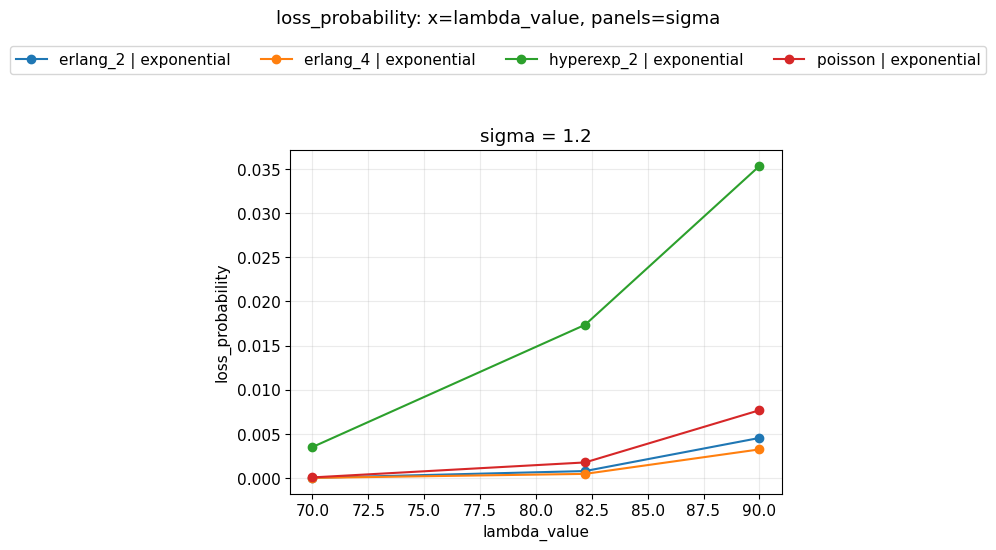

In [8]:
plot_metric_panels(
    base_metrics_df,
    metric=GRAPH_1_METRIC,
    x="lambda_value",
    panel="sigma",
    filters=GRAPH_1_FILTERS,
    suptitle=f"{GRAPH_1_METRIC}: x=lambda_value, panels=sigma",
)

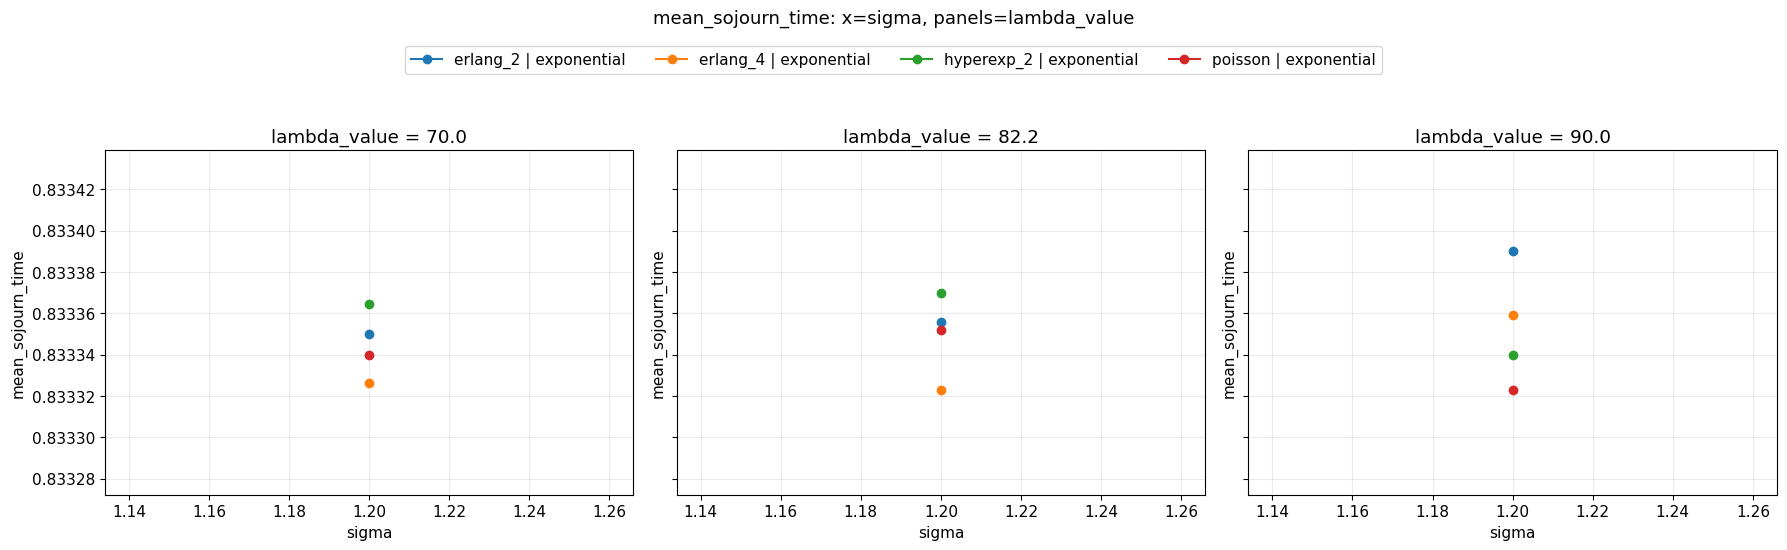

In [9]:
plot_metric_panels(
    base_metrics_df,
    metric=GRAPH_2_METRIC,
    x="sigma",
    panel="lambda_value",
    filters=GRAPH_2_FILTERS,
    suptitle=f"{GRAPH_2_METRIC}: x=sigma, panels=lambda_value",
)

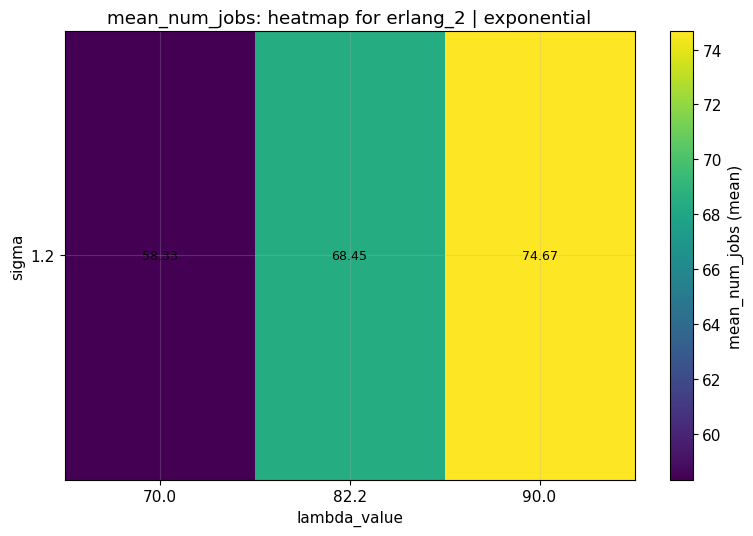

In [10]:
plot_heatmap(
    base_metrics_df,
    metric=GRAPH_3_METRIC,
    arrival=GRAPH_3_ARRIVAL,
    workload=GRAPH_3_WORKLOAD,
    title=f"{GRAPH_3_METRIC}: heatmap for {GRAPH_3_ARRIVAL} | {GRAPH_3_WORKLOAD}",
)

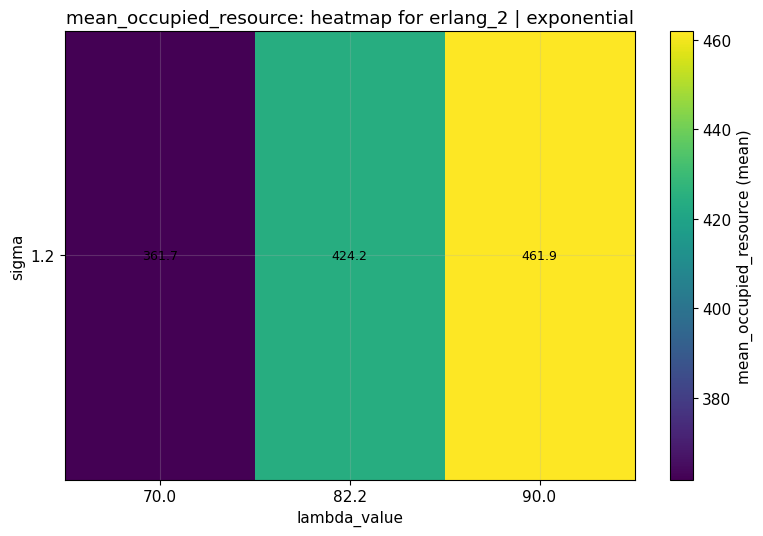

In [11]:
plot_heatmap(
    base_metrics_df,
    metric=GRAPH_4_METRIC,
    arrival=GRAPH_4_ARRIVAL,
    workload=GRAPH_4_WORKLOAD,
    title=f"{GRAPH_4_METRIC}: heatmap for {GRAPH_4_ARRIVAL} | {GRAPH_4_WORKLOAD}",
)

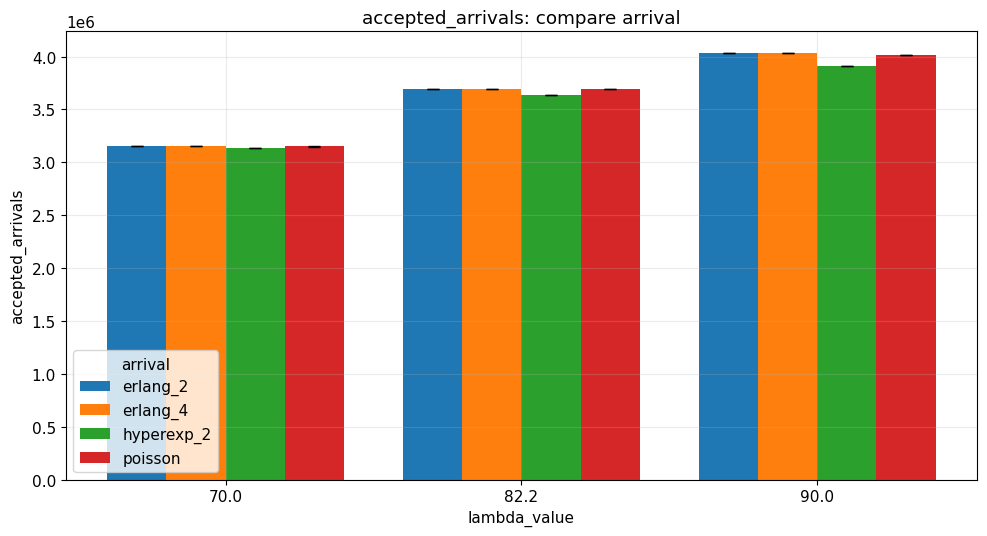

In [12]:
plot_grouped_bars(
    base_metrics_df,
    metric=GRAPH_5_METRIC,
    compare_col=GRAPH_5_COMPARE_COL,
    x_col="lambda_value",
    filters=GRAPH_5_FILTERS,
    title=f"{GRAPH_5_METRIC}: compare {GRAPH_5_COMPARE_COL}",
)

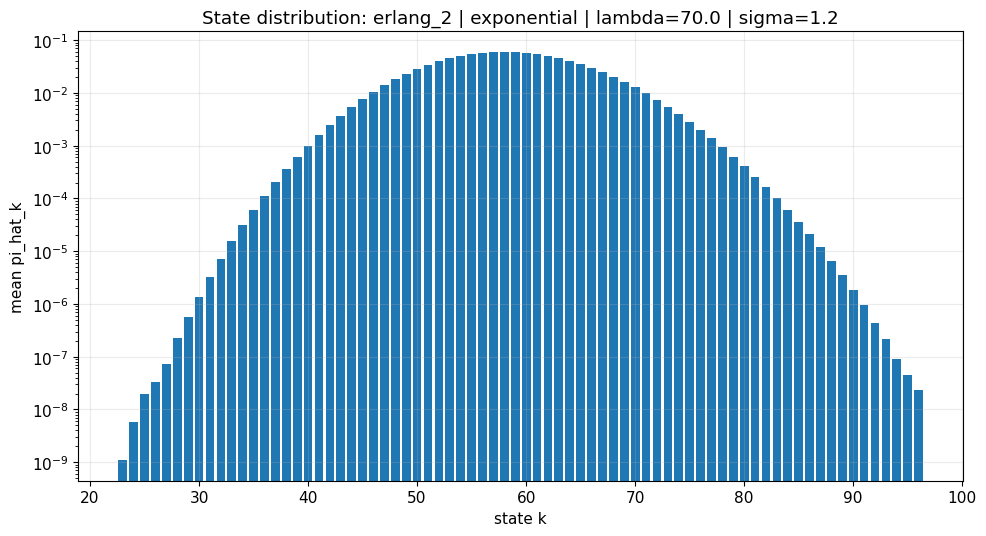

In [13]:
plot_pi_distribution(
    pi_df,
    arrival=GRAPH_6_ARRIVAL,
    workload=GRAPH_6_WORKLOAD,
    lambda_value=GRAPH_6_LAMBDA,
    sigma=GRAPH_6_SIGMA,
    positive_only=True,
    log_scale=True,
)